# Tutorial 06 — Build a Transformer from Scratch

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **How do the pieces of attention become a Transformer?**

---

## 1. Why this matters

Attention on its own is a single weighted average. A Transformer is attention
plus four unglamorous pieces — residual connections, layer normalisation, a
feed-forward block, and positional information — and it is those pieces, not
attention alone, that make the thing *stackable*. Stackability is what turned
a translation model into GPT-3, DINOv2, GraphCast and Chronos.

We build one here small enough to read in full and train on a laptop. The
objective is not to win the benchmark. It is that when tutorial 09 loads a
119-million-parameter pretrained forecaster, you know exactly what is inside
it, because you assembled the same thing yourself.

## 2. Historical context

*Attention Is All You Need* (2017) proposed an encoder-decoder for machine
translation. Within a year the field had split it in half and found that each
half was independently useful: BERT (2018) kept the encoder, GPT (2018) kept
the decoder. By 2020 the Vision Transformer showed the architecture had
nothing to do with language, and by 2024 the same blocks were forecasting
weather (GraphCast), predicting protein structure (ESM) and modelling
electricity demand (Chronos, PowerPM).

The block below is essentially unchanged since 2017. What changed is the data,
the scale, and the normalisation placement.

## 3. Learning objectives

By the end of this notebook you can:

- assemble a Transformer block from attention, residuals, LayerNorm and an MLP,
  and say what each part is for;
- explain what a "token" is when the data is a time series rather than text;
- explain why pre-norm replaced post-norm;
- distinguish encoder-only, decoder-only and encoder-decoder models and match
  each to the tasks it suits;
- compare a Transformer against the tutorial-03 LSTM on *identical* windows
  and report the result honestly;
- quantify the $O(n^2)$ cost and name the approaches that attack it.

In [1]:
from __future__ import annotations

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, scaled, set_seed
from ai_power_course.data import load_energy_data, make_windows, time_split
from ai_power_course.metrics import mae, point_metrics, skill_score
from ai_power_course.models.attention import causal_mask
from ai_power_course.models.forecasters import (
    LSTMForecaster,
    TransformerBlock,
    TransformerForecaster,
)
from ai_power_course.models.training import (
    Standardizer,
    TrainConfig,
    count_parameters,
    make_loader,
    predict,
    train_model,
)
from ai_power_course.plotting import plot_attention, plot_learning_curve, use_course_style
from ai_power_course.results import Leaderboard, leaderboard_table, record

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. Theory

### What is a token?

In text, a token is a subword and an embedding table maps it to a vector. In a
time series there is no vocabulary: one time step *is* a token, and a linear
layer lifts its measurements into $d_{\text{model}}$ dimensions.

| data | one token is | how it becomes a vector |
|---|---|---|
| text | a subword | lookup in an embedding table |
| image (ViT) | a 16x16 patch | linear projection of the pixels |
| time series | one time step (or a patch of steps) | linear projection of the channels |
| power grid (tutorial 10) | one bus | linear projection of its features |

The Transformer does not care. It sees a set of vectors plus positional
information — which is exactly why the architecture generalised out of NLP.

### The block

$$\mathbf{x} \leftarrow \mathbf{x} + \operatorname{MHA}(\operatorname{LN}(\mathbf{x}))$$
$$\mathbf{x} \leftarrow \mathbf{x} + \operatorname{FFN}(\operatorname{LN}(\mathbf{x}))$$

Four ingredients, each doing a specific job:

- **Multi-head attention** — mixes information *across positions*. It is the
  only operation in the block that lets one time step see another.
- **Feed-forward network** — transforms each position *independently*, usually
  expanding to $4d$ and back. This is where most of the parameters live and is
  widely believed to be where factual/pattern knowledge is stored.
- **Residual connections** — make each block an *edit* to a running
  representation rather than a replacement. Without them, gradients through 12
  blocks behave like the vanilla RNN in tutorial 03.
- **Layer normalisation** — keeps activations at a stable scale so the
  residual stream does not blow up as blocks accumulate.

### Pre-norm versus post-norm

The 2017 paper normalised *after* the sublayer: `LN(x + Sublayer(x))`. That
arrangement needs a learning-rate warm-up to train at all, because early
gradients through the un-normalised residual path are large. Pre-norm —
`x + Sublayer(LN(x))` — leaves a clean identity path from input to output and
trains without warm-up. Essentially every model after ~2020 uses pre-norm.

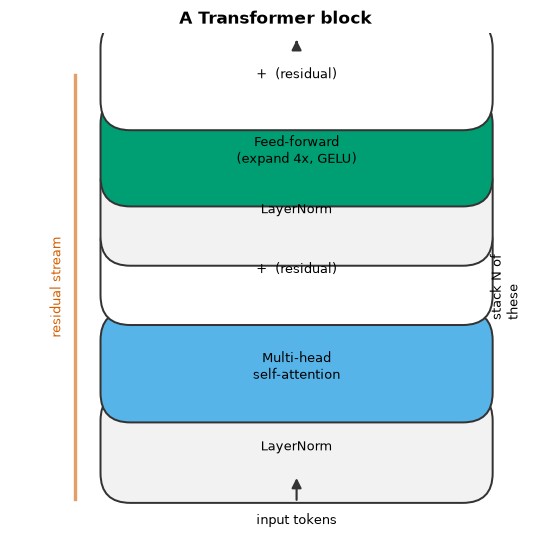

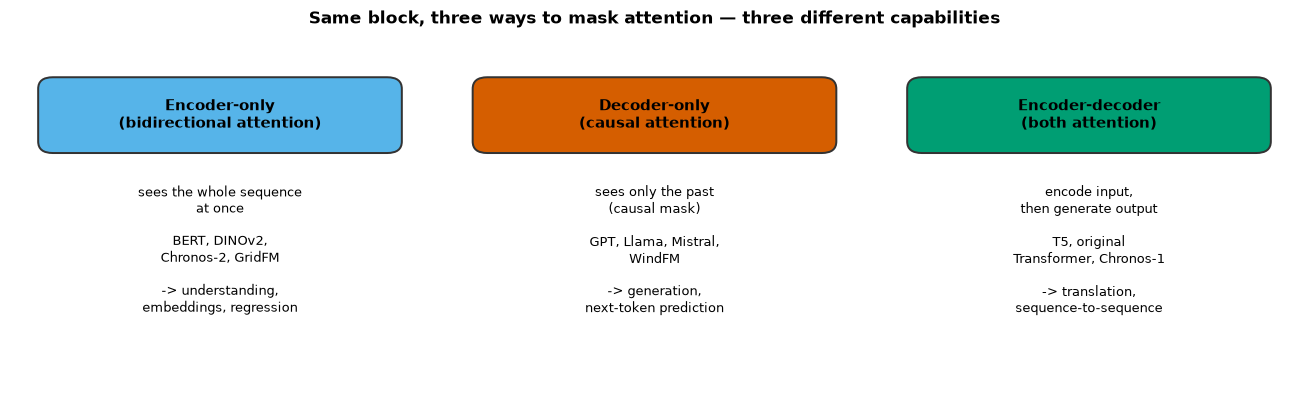

In [2]:
fig = diagrams.transformer_block()
plt.show()
fig = diagrams.encoder_decoder_variants()
plt.show()

## 5. From scratch: assembling one block

The package's `TransformerBlock` is the version we will train. Here we build
the same thing inline, one piece at a time, and check the two agree.

In [3]:
set_seed()
D_MODEL, N_HEADS, SEQ_LEN, BATCH = 32, 4, 12, 2
x = torch.randn(BATCH, SEQ_LEN, D_MODEL)

# --- piece 1: attention mixes across positions -------------------------------
attention = nn.MultiheadAttention(D_MODEL, N_HEADS, batch_first=True)
norm1 = nn.LayerNorm(D_MODEL)
attended, _ = attention(norm1(x), norm1(x), norm1(x), need_weights=False)
after_attention = x + attended                      # <- the residual

# --- piece 2: the feed-forward transforms each position independently ---------
norm2 = nn.LayerNorm(D_MODEL)
feed_forward = nn.Sequential(
    nn.Linear(D_MODEL, 4 * D_MODEL), nn.GELU(), nn.Linear(4 * D_MODEL, D_MODEL)
)
block_output = after_attention + feed_forward(norm2(after_attention))

print(f"input               {tuple(x.shape)}")
print(f"after attention     {tuple(after_attention.shape)}   <- shape never changes")
print(f"after feed-forward  {tuple(block_output.shape)}   <- which is why blocks stack")
print(f"\nparameters: attention {sum(p.numel() for p in attention.parameters()):,}, "
      f"feed-forward {sum(p.numel() for p in feed_forward.parameters()):,}")
print("Note where the parameters are: the feed-forward block holds about twice as many")
print("as attention. 'Transformer' is mostly a stack of MLPs with a mixing step between.")

input               (2, 12, 32)
after attention     (2, 12, 32)   <- shape never changes
after feed-forward  (2, 12, 32)   <- which is why blocks stack

parameters: attention 4,224, feed-forward 8,352
Note where the parameters are: the feed-forward block holds about twice as many
as attention. 'Transformer' is mostly a stack of MLPs with a mixing step between.


### Why the residual matters, measured

The claim from section 4: remove the residuals and gradients through a deep
stack collapse, exactly as in the vanilla RNN. Same measurement technique as
tutorial 03.

In [4]:
class Stack(nn.Module):
    """N blocks, with residual connections optionally disabled."""

    def __init__(self, n_blocks: int, residual: bool = True) -> None:
        super().__init__()
        self.residual = residual
        self.blocks = nn.ModuleList(
            nn.Sequential(nn.LayerNorm(D_MODEL),
                          nn.Linear(D_MODEL, D_MODEL), nn.GELU(),
                          nn.Linear(D_MODEL, D_MODEL))
            for _ in range(n_blocks)
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        for block in self.blocks:
            h = h + block(h) if self.residual else block(h)
        return h


rows = []
for depth in (2, 8, 24, 48):
    for residual in (True, False):
        torch.manual_seed(0)
        stack = Stack(depth, residual=residual)
        probe = torch.randn(1, SEQ_LEN, D_MODEL, requires_grad=True)
        stack(probe).sum().backward()
        rows.append({"depth": depth, "residual": residual,
                     "input gradient norm": float(probe.grad.norm())})

gradient_table = pd.DataFrame(rows).pivot(
    index="depth", columns="residual", values="input gradient norm")
gradient_table.columns = ["without residuals", "with residuals"]
display(gradient_table.round(6))

print("Without residuals the gradient reaching the input decays by orders of magnitude")
print("as depth grows; with them it stays on the same scale. That is the whole reason a")
print("96-layer model is trainable, and it is the same additive-path argument that made")
print("the LSTM's cell state work in tutorial 03.")

,without residuals,with residuals
depth,,
2,3.218728,20.324018
8,0.803230,23.805777
24,1.416588,28.361679
48,0.002371,35.599731


Without residuals the gradient reaching the input decays by orders of magnitude
as depth grows; with them it stays on the same scale. That is the whole reason a
96-layer model is trainable, and it is the same additive-path argument that made
the LSTM's cell state work in tutorial 03.


In [5]:
# Our package block should behave like the inline version we just built.
set_seed()
package_block = TransformerBlock(D_MODEL, N_HEADS, dropout=0.0)
package_block.eval()
out, weights = package_block(x, need_weights=True)
print(f"TransformerBlock output {tuple(out.shape)}, weights {tuple(weights.shape)}")
print(f"parameters: {count_parameters(package_block):,}")

TransformerBlock output (2, 12, 32), weights (2, 4, 12, 12)
parameters: 12,704


## 6. Encoder, decoder, encoder-decoder

One block, three ways to wire it. The only difference is the mask.

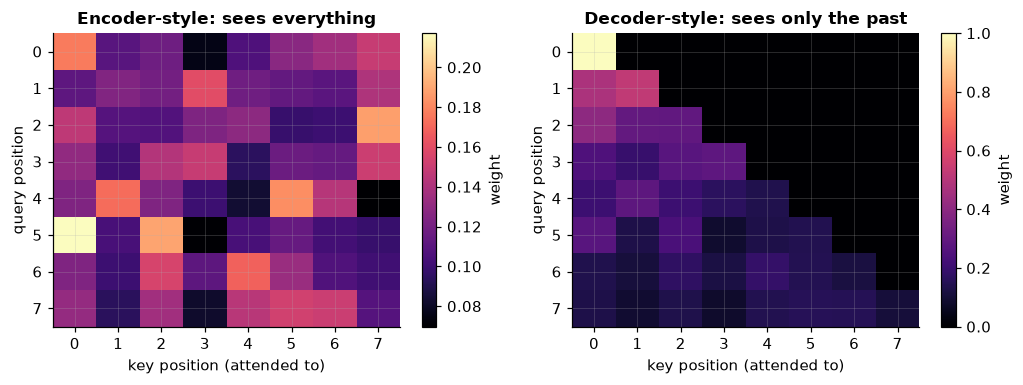

,attention,can generate?,good at,examples
encoder-only,bidirectional,no,"understanding, embeddings, regression","BERT, DINOv2, Chronos-2, GridFM"
decoder-only,causal,yes,"generation, next-token prediction","GPT, Llama, Mistral, WindFM"
encoder-decoder,causal + cross,yes,mapping one sequence to another,"T5, original Transformer, Chronos-1"


For fixed-horizon forecasting we want an ENCODER. There is nothing to generate
token by token — we want a rich representation of the context, read out once.
Chronos-2 made the same choice; Chronos-1 was encoder-decoder. Tutorial 07 uses
a decoder, because generating text really is one token at a time.


In [6]:
set_seed()
short = torch.randn(1, 8, D_MODEL)
encoder_block = TransformerBlock(D_MODEL, N_HEADS, dropout=0.0).eval()

_, bidirectional = encoder_block(short, need_weights=True)
_, causal = encoder_block(short, mask=causal_mask(8), need_weights=True)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6))
plot_attention(bidirectional[0, 0].detach().numpy(),
               title="Encoder-style: sees everything", tick_step=1, ax=axes[0])
plot_attention(causal[0, 0].detach().numpy(),
               title="Decoder-style: sees only the past", tick_step=1, ax=axes[1])
fig.tight_layout()
plt.show()

comparison = pd.DataFrame(
    {
        "attention": ["bidirectional", "causal", "causal + cross"],
        "can generate?": ["no", "yes", "yes"],
        "good at": ["understanding, embeddings, regression",
                    "generation, next-token prediction",
                    "mapping one sequence to another"],
        "examples": ["BERT, DINOv2, Chronos-2, GridFM",
                     "GPT, Llama, Mistral, WindFM",
                     "T5, original Transformer, Chronos-1"],
    },
    index=["encoder-only", "decoder-only", "encoder-decoder"],
)
display(comparison)

print("For fixed-horizon forecasting we want an ENCODER. There is nothing to generate")
print("token by token — we want a rich representation of the context, read out once.")
print("Chronos-2 made the same choice; Chronos-1 was encoder-decoder. Tutorial 07 uses")
print("a decoder, because generating text really is one token at a time.")

## 7. Power-system application

**Same window DEFINITION as tutorial 03** — same context, same horizon, same
channels, same splits, same standardisation — but *not* the same number of
windows: `TRAIN_STRIDE = 4` below takes every fourth training origin, giving
4,333 training windows where tutorial 03 used 17,329.

That is deliberate and it is fine for the comparison made *inside this
notebook*, because the LSTM is retrained here on exactly the same stride-4
data. It is not fine for reading tutorial 03's numbers across: that LSTM saw
four times as many training windows, so the leaderboard rows are not a
like-for-like fight even though the architectures are both "trained on the
same windows".

In [7]:
CONTEXT, HORIZON = 168, 24

# Consecutive windows overlap by 167 of 168 hours, so a stride-1 training set is
# enormously redundant. Taking every fourth origin keeps full coverage of the
# period, cuts the training set (and the training time) fourfold, and costs
# almost nothing in accuracy. Test windows stay at stride 1 so the per-lead-time
# curve uses every available origin.
TRAIN_STRIDE = 4

frame = load_energy_data().frame
train_raw, valid_raw, test_raw = time_split(frame)


def channel_frame(part: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=part.index)
    out["load_mw"] = part.load_mw
    out["hour_sin"] = np.sin(2 * np.pi * part.index.hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * part.index.hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * part.index.dayofweek / 7)
    out["dow_cos"] = np.cos(2 * np.pi * part.index.dayofweek / 7)
    out["temperature_c"] = part.temperature_c
    return out


def build_windows(part: pd.DataFrame, history: pd.DataFrame | None = None,
                  stride: int = 1):
    channels = channel_frame(part)
    if history is not None:
        channels = pd.concat([channel_frame(history).tail(CONTEXT), channels])
    x, y = make_windows(channels["load_mw"], context=CONTEXT, horizon=HORIZON,
                        stride=stride, covariates=channels.drop(columns="load_mw"))
    target_index = channels.index[CONTEXT + HORIZON - 1 : len(channels)][::stride]
    return x, y, target_index[: len(y)]


x_train, y_train, _ = build_windows(train_raw, stride=TRAIN_STRIDE)
x_valid, y_valid, _ = build_windows(valid_raw, history=train_raw, stride=TRAIN_STRIDE)
x_test, y_test_seq, idx_test = build_windows(test_raw, history=valid_raw, stride=1)

scaler = Standardizer().fit(x_train.reshape(-1, x_train.shape[2]), axis=0)
reshape = lambda a: scaler.transform(a.reshape(-1, a.shape[2])).reshape(a.shape)  # noqa: E731
xs_train, xs_valid, xs_test = (reshape(a) for a in (x_train, x_valid, x_test))
target_scaler = Standardizer().fit(y_train)
ys_train, ys_valid = target_scaler.transform(y_train), target_scaler.transform(y_valid)

y_test_point = y_test_seq[:, -1]
ORIGIN_POSITION = CONTEXT - 1
n_channels = xs_train.shape[2]

print(f"x_train {x_train.shape}  (stride {TRAIN_STRIDE})")
print(f"y_train {y_train.shape}  channels {n_channels}")
print(f"test windows {idx_test[0]:%Y-%m-%d} to {idx_test[-1]:%Y-%m-%d}")

x_train (4333, 168, 6)  (stride 4)
y_train (4333, 24)  channels 6
test windows 2020-01-01 to 2020-12-31


In [8]:
def train_and_score(model: nn.Module, label: str, epochs: int, learning_rate: float = 1e-3):
    set_seed()
    started = time.perf_counter()
    history = train_model(
        model,
        make_loader(xs_train, ys_train, batch_size=64, shuffle=True),
        make_loader(xs_valid, ys_valid, batch_size=256),
        loss_fn=nn.MSELoss(),
        config=TrainConfig(epochs=epochs, learning_rate=learning_rate, patience=6, verbose=False),
    )
    seconds = time.perf_counter() - started
    prediction = target_scaler.inverse_transform(predict(model, xs_test))
    started_inference = time.perf_counter()
    predict(model, xs_test[:1024])
    inference_ms = (time.perf_counter() - started_inference) / 1024 * 1000
    print(f"{label:28s} params {count_parameters(model):8,}  epoch {history.best_epoch:3d}  "
          f"train {seconds:6.1f}s  infer {inference_ms:.3f} ms/window  "
          f"MAE(t+24) {mae(y_test_point, prediction[:, -1]):8,.1f} MW")
    return prediction, history, seconds, inference_ms


EPOCHS = scaled(full=15, fast=2)
n_layers_grid = [1, 2, 4] if not fast_mode() else [1, 2]

set_seed()
lstm = LSTMForecaster(n_channels, hidden_size=64, num_layers=1, horizon=HORIZON)
lstm_prediction, lstm_history, lstm_seconds, lstm_ms = train_and_score(
    lstm, "LSTM (tutorial 03 model)", EPOCHS)

LSTM (tutorial 03 model)     params   19,992  epoch  11  train   21.0s  infer 0.035 ms/window  MAE(t+24)  1,774.9 MW


### 7.1 Does depth help?

The depth sweep doubles as the main experiment: the two-layer model from this
table is the "Transformer" used everywhere below, so nothing is trained twice.

In [9]:
depth_rows, trained = [], {}
for n_layers in n_layers_grid:
    set_seed()
    candidate = TransformerForecaster(
        context=CONTEXT, horizon=HORIZON, n_channels=n_channels,
        d_model=64, n_heads=4, n_layers=n_layers, dropout=0.1,
    )
    prediction, history, seconds, inference_ms = train_and_score(
        candidate, f"Transformer ({n_layers} layer{'s' if n_layers > 1 else ''})", EPOCHS)
    trained[n_layers] = (candidate, prediction, history, seconds, inference_ms)
    depth_rows.append({
        "layers": n_layers,
        "parameters": count_parameters(candidate),
        "MAE": mae(y_test_point, prediction[:, -1]),
        "train seconds": round(seconds, 1),
    })

depth_table = pd.DataFrame(depth_rows).set_index("layers")
display(depth_table.round(2))

# The two-layer model is "the" Transformer from here on.
transformer, transformer_prediction, transformer_history, transformer_seconds, transformer_ms = (
    trained[2]
)

print("\nMore layers is not automatically better on a few thousand training windows.")
print("Depth buys capacity, and capacity needs data to pay for itself — which is the")
print("argument in the scaling-law literature, and the reason a foundation model is")
print("pretrained on far more data than any single task provides.")

Transformer (1 layer)        params   52,120  epoch  14  train  130.1s  infer 0.212 ms/window  MAE(t+24)  1,606.4 MW


Transformer (2 layers)       params  102,104  epoch  14  train  281.1s  infer 0.425 ms/window  MAE(t+24)  1,602.9 MW


Transformer (4 layers)       params  202,072  epoch  14  train  598.5s  infer 0.848 ms/window  MAE(t+24)  1,628.3 MW


,parameters,MAE,train seconds
layers,,,
1,52120,1606.43,130.1
2,102104,1602.93,281.1
4,202072,1628.29,598.5



More layers is not automatically better on a few thousand training windows.
Depth buys capacity, and capacity needs data to pay for itself — which is the
argument in the scaling-law literature, and the reason a foundation model is
pretrained on far more data than any single task provides.


## 8. Baseline comparison

Everything on the identical test windows, including the trivial baselines,
aligned the same way as tutorial 03.

In [10]:
persistence_point = x_test[:, ORIGIN_POSITION, 0]
weekly_point = x_test[:, ORIGIN_POSITION - (168 - HORIZON), 0]
assert np.allclose(persistence_point,
                   frame.load_mw.reindex(idx_test - pd.Timedelta(hours=HORIZON)))
assert np.allclose(weekly_point, frame.load_mw.reindex(idx_test - pd.Timedelta(hours=168)))

predictions = {
    "Persistence (= seasonal naive 24 h)": persistence_point,
    "Seasonal naive (168 h)": weekly_point,
    "LSTM": lstm_prediction[:, -1],
    "Transformer": transformer_prediction[:, -1],
}
reference = predictions["Seasonal naive (168 h)"]
results = pd.DataFrame(
    {name: {**point_metrics(y_test_point, values),
            "Skill": skill_score(y_test_point, values, reference)}
     for name, values in predictions.items()}
).T.sort_values("MAE")
display(results.round(3))

,MAE,RMSE,R2,Bias,MAPE_%,Skill
Transformer,1602.925,2200.132,0.895,269.344,3.009,0.271
LSTM,1774.868,2385.607,0.877,334.051,3.349,0.210
Seasonal naive (168 h),2262.963,3018.770,0.803,-20.707,4.197,0.000
Persistence (= seasonal naive 24 h),3355.265,4590.985,0.545,6.533,6.356,-0.521


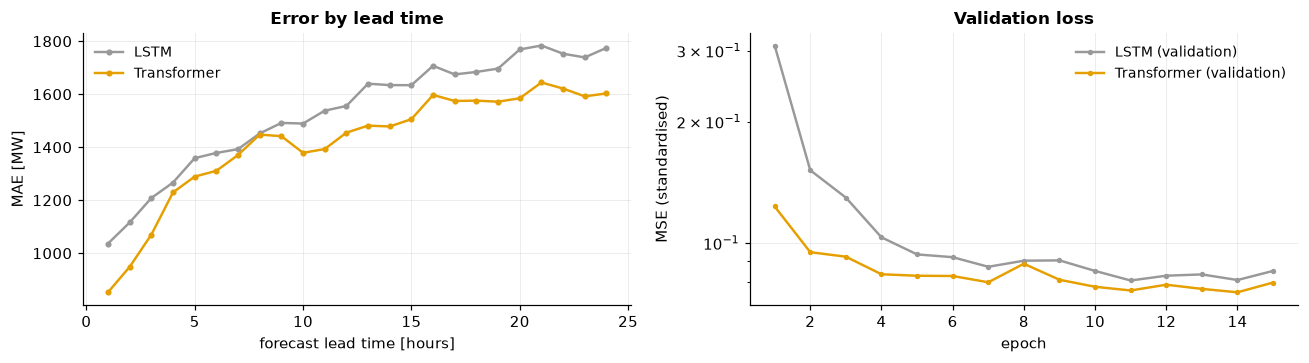

Transformer vs. LSTM at t+24: 9.7% lower MAE
Training time: LSTM 21s, Transformer 281s (13.4x the LSTM)
Inference:     LSTM 0.035 ms/window, Transformer 0.425 ms/window
Parameters:    LSTM 19,992, Transformer 102,104


In [11]:
per_step = pd.DataFrame(
    {"LSTM": [mae(y_test_seq[:, h], lstm_prediction[:, h]) for h in range(HORIZON)],
     "Transformer": [mae(y_test_seq[:, h], transformer_prediction[:, h]) for h in range(HORIZON)]},
    index=np.arange(1, HORIZON + 1),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for name in per_step.columns:
    axes[0].plot(per_step.index, per_step[name], marker="o", ms=3, label=name)
axes[0].set_xlabel("forecast lead time [hours]")
axes[0].set_ylabel("MAE [MW]")
axes[0].set_title("Error by lead time")
axes[0].legend()
plot_learning_curve(
    {"LSTM (validation)": lstm_history.val_loss,
     "Transformer (validation)": transformer_history.val_loss},
    title="Validation loss", ylabel="MSE (standardised)", ax=axes[1],
)
fig.tight_layout()
plt.show()

gap = mae(y_test_point, transformer_prediction[:, -1]) / mae(y_test_point, lstm_prediction[:, -1]) - 1
direction = "lower" if gap < 0 else "higher"
print(f"Transformer vs. LSTM at t+24: {abs(gap):.1%} {direction} MAE")
print(f"Training time: LSTM {lstm_seconds:.0f}s, Transformer {transformer_seconds:.0f}s "
      f"({transformer_seconds / max(lstm_seconds, 1e-9):.1f}x the LSTM)")
print(f"Inference:     LSTM {lstm_ms:.3f} ms/window, Transformer {transformer_ms:.3f} ms/window")
print(f"Parameters:    LSTM {count_parameters(lstm):,}, "
      f"Transformer {count_parameters(transformer):,}")

**The timing result is the opposite of the folklore, and it is worth getting
right.**

On this machine — a CPU with four threads and a 168-step context — the
Transformer is *slower* to train than the LSTM, by a substantial factor. That
is not a bug and not a bad implementation. It is arithmetic:

- The Transformer applies a full feed-forward block at **every one of the 168
  positions**, then attends across all pairs of positions. Work per example
  scales as $O(L \cdot d^2 + L^2 \cdot d)$, and at $L=168$, $d=64$ the first
  term already dominates everything the LSTM does.
- The LSTM applies one small recurrent cell per step and decodes only the
  final hidden state. Work per example scales as $O(L \cdot d^2)$ with a much
  smaller constant, and it never builds an $L \times L$ anything.

So the Transformer does considerably *more* arithmetic. What it does not do is
**sequential** arithmetic:

| | total work | sequential steps |
|---|---|---|
| LSTM | lower | $O(L)$ — step $t$ needs step $t-1$ |
| Transformer | higher | $O(1)$ — all positions at once |

Four CPU threads cannot exploit that. Thousands of GPU cores can, and at that
point "more arithmetic, all of it parallel" beats "less arithmetic, strictly
serial" by a wide margin — which is why the architecture scaled and the LSTM
did not.

The lesson for your own work: **the architecture that wins depends on the
hardware you have.** If you are training on a laptop with sequences of a few
hundred steps, an LSTM or a gradient-boosted model may genuinely be the better
engineering choice, and tutorials 01 to 03 have already shown they are
competitive on accuracy. Report the machine alongside the timing.

## 9. Inspect the model

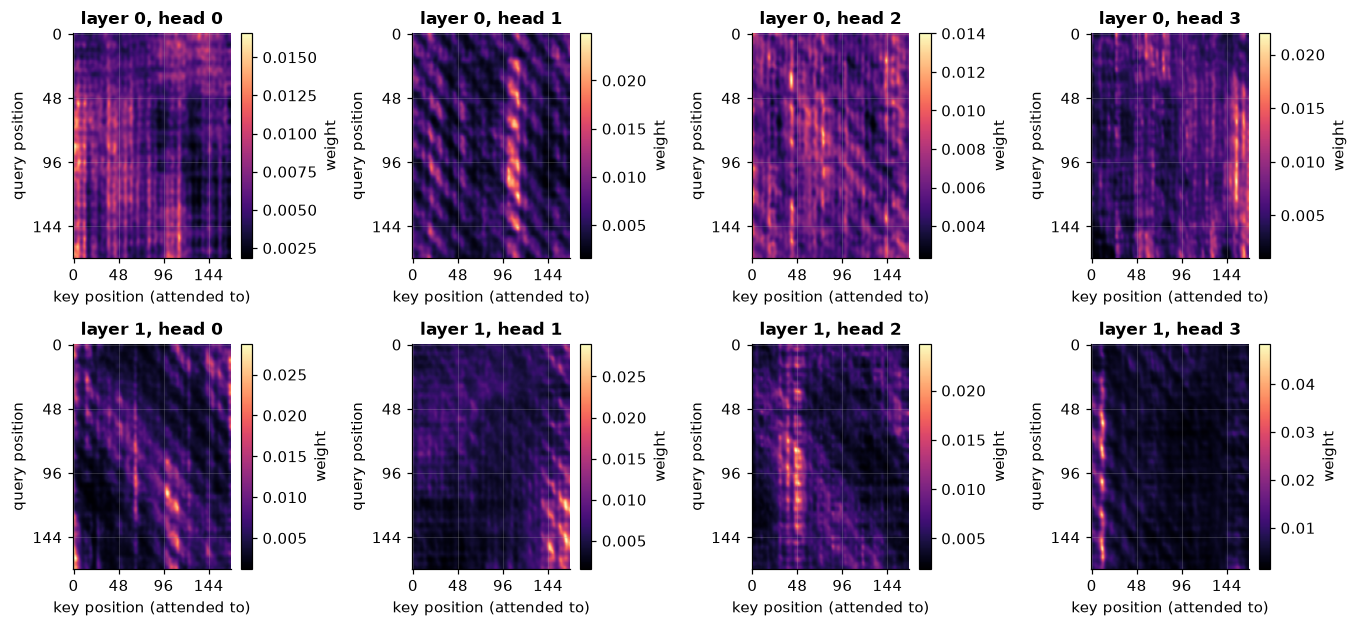

In [12]:
transformer.eval()
with torch.no_grad():
    sample = torch.tensor(xs_test[:256], dtype=torch.float32)
    _, all_weights = transformer(sample, need_weights=True)
# (batch, layer, head, query, key) -> average over the batch
attention_maps = all_weights.mean(dim=0).numpy()
n_layers_actual, n_heads_actual = attention_maps.shape[0], attention_maps.shape[1]

fig, axes = plt.subplots(n_layers_actual, n_heads_actual,
                         figsize=(3.1 * n_heads_actual, 2.9 * n_layers_actual), squeeze=False)
for layer in range(n_layers_actual):
    for head in range(n_heads_actual):
        plot_attention(attention_maps[layer, head], title=f"layer {layer}, head {head}",
                       tick_step=48, ax=axes[layer][head])
fig.tight_layout()
plt.show()

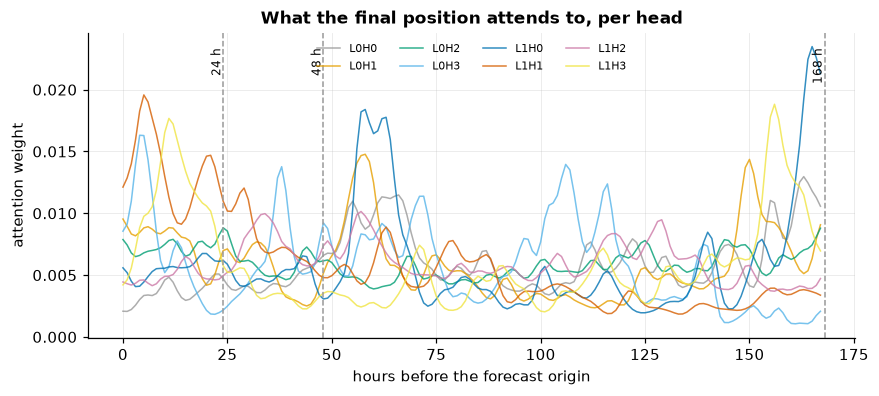

,entropy,weight on last 12 h,weight on 24 +/- 3 h,uniform entropy
L0H0,5.044,0.039,0.032,5.124
L0H1,5.018,0.104,0.040,5.124
L0H2,5.106,0.085,0.055,5.124
L0H3,4.950,0.127,0.015,5.124
L1H0,4.917,0.060,0.043,5.124
L1H1,4.934,0.185,0.087,5.124
L1H2,5.089,0.054,0.034,5.124
L1H3,4.947,0.121,0.053,5.124



8 of 8 heads have an entropy within 5% of the
uniform value — they are close to plain averaging rather than selecting. That is
a real finding about this small model on this task, not a rendering artefact, and
it is worth more than a paragraph of interpretation of the prettier heads.

Remember tutorial 05's warning before reading these as explanations: the weights
say where the model looked, not what changed its answer. The residual stream
carries information past attention entirely.


In [13]:
# The final position is where the forecast is read from.
final_rows = attention_maps[:, :, -1, :]                  # (layer, head, key)
lags = np.arange(CONTEXT)[::-1]

fig, ax = plt.subplots(figsize=(9, 3.6))
for layer in range(n_layers_actual):
    for head in range(n_heads_actual):
        ax.plot(lags, final_rows[layer, head], lw=1.0, alpha=0.8,
                label=f"L{layer}H{head}")
for marker in (24, 48, 168):
    if marker <= CONTEXT:
        ax.axvline(marker, ls="--", color="#999", lw=1)
        ax.text(marker, ax.get_ylim()[1] * 0.95, f"{marker} h", rotation=90,
                fontsize=8, ha="right", va="top")
ax.set_xlabel("hours before the forecast origin")
ax.set_ylabel("attention weight")
ax.set_title("What the final position attends to, per head")
ax.legend(ncol=4, fontsize=7.5)
plt.show()

concentration = pd.DataFrame(
    {
        "entropy": [-np.sum(r * np.log(r + 1e-12))
                    for r in final_rows.reshape(-1, CONTEXT)],
        "weight on last 12 h": final_rows.reshape(-1, CONTEXT)[:, -12:].sum(axis=1),
        "weight on 24 +/- 3 h": final_rows.reshape(-1, CONTEXT)[:, CONTEXT - 27:CONTEXT - 20].sum(axis=1),
    },
    index=[f"L{layer}H{head}" for layer in range(n_layers_actual)
           for head in range(n_heads_actual)],
)
concentration["uniform entropy"] = np.log(CONTEXT)
display(concentration.round(3))

near_uniform = (concentration.entropy > 0.95 * np.log(CONTEXT)).sum()
print(f"\n{near_uniform} of {len(concentration)} heads have an entropy within 5% of the\n"
      "uniform value — they are close to plain averaging rather than selecting. That is\n"
      "a real finding about this small model on this task, not a rendering artefact, and\n"
      "it is worth more than a paragraph of interpretation of the prettier heads.")
print("\nRemember tutorial 05's warning before reading these as explanations: the weights")
print("say where the model looked, not what changed its answer. The residual stream")
print("carries information past attention entirely.")

## 10. The cost of attention, and what people do about it

Attention is $O(n^2)$ in sequence length. Let us put real numbers on it for
*this* model rather than quoting the asymptotics.

In [14]:
cost_rows = []
for context in (24, 168, 512, 1024):
    set_seed()
    probe = TransformerForecaster(context=context, horizon=HORIZON, n_channels=n_channels,
                                  d_model=64, n_heads=4, n_layers=2)
    batch = torch.randn(4, context, n_channels)
    probe.eval()
    with torch.no_grad():
        probe(batch)                       # warm up, then time
        started = time.perf_counter()
        for _ in range(3):
            probe(batch, need_weights=True)   # force the explicit L x L matrix
        elapsed = (time.perf_counter() - started) / 3 / 4 * 1000
    cost_rows.append({
        "context": context,
        "parameters": count_parameters(probe),
        "attention entries per head per layer": context * context,
        "activation memory [MB]": 2 * 4 * context * context * 4 / 1e6,
        "forward ms/window": round(elapsed, 3),
    })
cost = pd.DataFrame(cost_rows).set_index("context")
display(cost)

ratio = cost["forward ms/window"].iloc[-1] / cost["forward ms/window"].iloc[0]
length_ratio = cost.index[-1] / cost.index[0]
print(f"Context grew {length_ratio:.0f}x; forward time grew {ratio:.0f}x.")
print("Note the parameter count barely moves — the cost is in activations, not weights.")
print("\nThese timings force the explicit attention path so the L x L matrix is really\n"
      "built. Training above uses PyTorch's fused kernel, which computes the same\n"
      "function without ever materialising that matrix — the reason FlashAttention\n"
      "exists, and the reason you cannot ask a fused kernel for its weights.")
print("\nThree families of responses, none of which this course implements:")
print("  * cheaper exact attention  — FlashAttention: same maths, IO-aware kernels")
print("  * approximate attention    — sparse, local or linear attention patterns")
print("  * a different operator     — state-space models (Mamba, Gu & Dao 2023) are")
print("                               linear in sequence length and competitive on")
print("                               long sequences; several 2025-26 time-series")
print("                               foundation models use them or hybrids.")
print("\nFor power-system time series the quadratic cost bites sooner than people expect:")
print("a year of 15-minute SCADA data is 35,040 steps.")

,parameters,attention entries per head per layer,activation memory [MB],forward ms/window
context,,,,
24,102104,576,0.018432,0.301
168,102104,28224,0.903168,0.721
512,102104,262144,8.388608,2.115
1024,102104,1048576,33.554432,31.454


Context grew 43x; forward time grew 104x.
Note the parameter count barely moves — the cost is in activations, not weights.

These timings force the explicit attention path so the L x L matrix is really
built. Training above uses PyTorch's fused kernel, which computes the same
function without ever materialising that matrix — the reason FlashAttention
exists, and the reason you cannot ask a fused kernel for its weights.

Three families of responses, none of which this course implements:
  * cheaper exact attention  — FlashAttention: same maths, IO-aware kernels
  * approximate attention    — sparse, local or linear attention patterns
  * a different operator     — state-space models (Mamba, Gu & Dao 2023) are
                               linear in sequence length and competitive on
                               long sequences; several 2025-26 time-series
                               foundation models use them or hybrids.

For power-system time series the quadratic cost bites sooner

## 11. Failure analysis

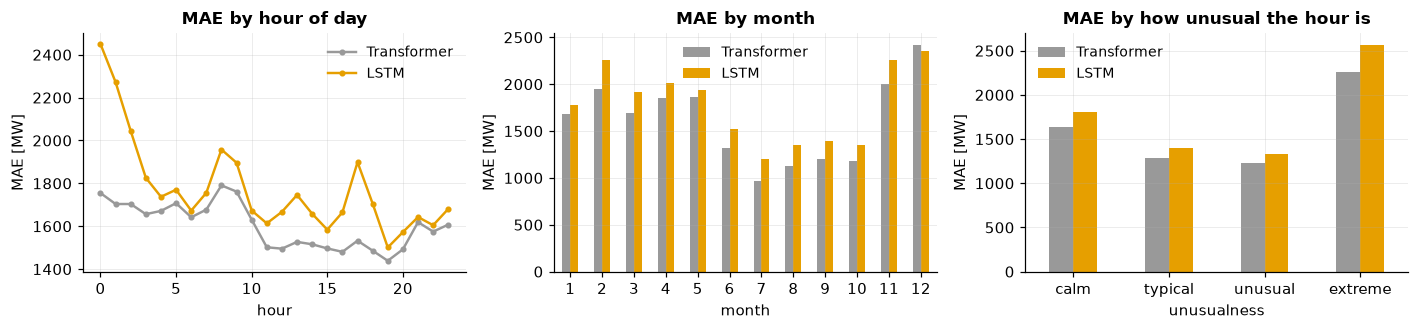

Correlation between the two models' errors: r = 0.804
Mean |Transformer - LSTM| prediction difference: 845 MW

Simple average of the two          : MAE 1,636.4 MW
Best single model                  : MAE 1,602.9 MW

Highly correlated errors mean the two architectures are failing on the *same*
hours — so their disagreement carries little extra information and averaging them
buys little. When an ensemble does not help, it usually means the difficulty is
in the data, not in the model class.


In [15]:
transformer_point = transformer_prediction[:, -1]
lstm_point = lstm_prediction[:, -1]

profile = train_raw.load_mw.groupby(
    [train_raw.index.hour, train_raw.index.dayofweek]).mean()
expected = np.array([profile.get((h, d), float(train_raw.load_mw.mean()))
                     for h, d in zip(idx_test.hour, idx_test.dayofweek, strict=True)])

errors = pd.DataFrame(
    {
        "Transformer": np.abs(transformer_point - y_test_point),
        "LSTM": np.abs(lstm_point - y_test_point),
        "hour": idx_test.hour,
        "month": idx_test.month,
        "unusualness": np.abs(y_test_point - expected),
    },
    index=idx_test,
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.1))
errors.groupby("hour")[["Transformer", "LSTM"]].mean().plot(ax=axes[0], marker="o", ms=3,
                                                            title="MAE by hour of day")
errors.groupby("month")[["Transformer", "LSTM"]].mean().plot(kind="bar", ax=axes[1],
                                                             title="MAE by month")
quartiles = pd.qcut(errors.unusualness, 4, labels=["calm", "typical", "unusual", "extreme"])
errors.groupby(quartiles, observed=True)[["Transformer", "LSTM"]].mean().plot(
    kind="bar", ax=axes[2], title="MAE by how unusual the hour is")
for ax in axes:
    ax.set_ylabel("MAE [MW]")
    ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

agreement = np.corrcoef(errors.Transformer, errors.LSTM)[0, 1]
print(f"Correlation between the two models' errors: r = {agreement:.3f}")
print(f"Mean |Transformer - LSTM| prediction difference: "
      f"{np.abs(transformer_point - lstm_point).mean():,.0f} MW")
blend = 0.5 * (transformer_point + lstm_point)
print(f"\nSimple average of the two          : MAE {mae(y_test_point, blend):,.1f} MW")
print(f"Best single model                  : MAE {min(mae(y_test_point, transformer_point), mae(y_test_point, lstm_point)):,.1f} MW")
print("\nHighly correlated errors mean the two architectures are failing on the *same*")
print("hours — so their disagreement carries little extra information and averaging them")
print("buys little. When an ensemble does not help, it usually means the difficulty is")
print("in the data, not in the model class.")

## 12. Record the result

In [16]:
Leaderboard().clear(tutorial=6)
record(
    model="Transformer (encoder, 2 layers)",
    tutorial=6,
    metrics={**point_metrics(y_test_point, transformer_point),
             "Skill": skill_score(y_test_point, transformer_point, reference)},
    n_parameters=count_parameters(transformer),
    train_seconds=transformer_seconds,
    notes=f"raw {CONTEXT} h window, {n_channels} channels, stride-{TRAIN_STRIDE} training",
)
display(leaderboard_table())

Bias       MAE  \
Tutorial Model                                                           
6        Transformer (encoder, 2 layers)             269.344  1602.925   
2        MLP (2 hidden layers)                        72.396  1624.032   
1        Random forest                               228.205  1636.504   
3        LSTM                                        475.708  1639.269   
         Vanilla RNN                                 568.151  1686.095   
1        Gradient boosting                           574.800  1776.462   
         Linear regression                           359.230  2066.153   
         seasonal naive (168 h)                       51.785  2218.972   
         climatology (hour x weekday)                973.565  3092.499   
         persistence (h=24) = seasonal naive (24 h)   30.224  3358.186   

                                                     MAPE_%     R2      RMSE  \
Tutorial Model                                                                 
6        Transformer (encoder, 2 layers)              3.009  0.895  2200.132   
2        MLP (2 hidden layers)                        3.047  0.896  2190.210   
1        Random forest                                3.067  0.889  2260.824   
3        LSTM                                         3.083  0.890  2260.473   
         Vanilla RNN                                  3.189  0.886  2296.802   
1        Gradient boosting                            3.345  0.875  2400.515   
         Linear regression                            3.892  0.847  2651.899   
         seasonal naive (168 h)                       4.130  0.811  2952.957   
         climatology (hour x weekday)                 5.864  0.715  3623.821   
         persistence (h=24) = seasonal naive (24 h)   6.372  0.541  4600.202   

                                                     Skill  \
Tutorial Model                                               
6        Transformer (encoder, 2 layers)             0.271   
2        MLP (2 hidden layers)                       0.258   
1        Random forest                               0.234   
3        LSTM                                        0.251   
         Vanilla RNN                                 0.239   
1        Gradient boosting                           0.187   
         Linear regression                           0.102   
         seasonal naive (168 h)                      0.000   
         climatology (hour x weekday)               -0.227   
         persistence (h=24) = seasonal naive (24 h) -0.558   

                                                                                               Notes  \
Tutorial Model                                                                                         
6        Transformer (encoder, 2 layers)             raw 168 h window, 6 channels, stride-4 training   
2        MLP (2 hidden layers)                               same engineered features as tutorial 01   
1        Random forest                                            engineered lag + calendar features   
3        LSTM                                                           raw 168 h window, 6 channels   
         Vanilla RNN                                                    raw 168 h window, 6 channels   
1        Gradient boosting                                        engineered lag + calendar features   
         Linear regression                                        engineered lag + calendar features   
         seasonal naive (168 h)                                                     trivial baseline   
         climatology (hour x weekday)                                               trivial baseline   
         persistence (h=24) = seasonal naive (24 h)                                 trivial baseline   

                                                       Params  Train_s  
Tutorial Model                                                          
6        Transformer (encoder, 2 layers)             102104.0    2

## 13. Exercises

**1 — Conceptual.** This Transformer treats each hour as one token, giving a
168-token sequence. Modern time-series models (PatchTST, Chronos-2, TimesFM)
instead group consecutive steps into *patches* — say 16 hours per token — and
report both better accuracy and much lower cost. Work out why patching helps
on both axes, and what it costs you. Then decide what the right patch size
would be for 15-minute SCADA data, and justify it in terms of the physical
time-scales in a power system.

**2 — Coding.** Set `causal=True` when constructing `TransformerForecaster`
and retrain. The causal mask stops each position attending to later ones,
which should be *irrelevant* here — we only read out the final position, which
sees everything either way. Confirm that empirically, then explain why a
causal mask nonetheless changes what the *intermediate* positions can learn,
and what that implies for using this model as a pretrained backbone.

**3 — Research.** Section 10 measured the quadratic cost. Implement *local*
attention — each position may attend only within a window of $w$ steps — by
passing a banded mask, and measure accuracy and forward time for
$w \in \{6, 24, 72, 168\}$. At what window does accuracy stop improving?
Compare that number to the physical memory of the system (how long does a
load level stay informative?) and write a paragraph on whether full attention
was ever necessary for this problem.

## 14. Key takeaways

- **A Transformer block is attention + feed-forward + residuals + LayerNorm.**
  Most of the parameters are in the feed-forward part, and most of the
  *trainability* comes from the residuals — we measured gradients collapsing
  without them.
- **A token is whatever you project into $d_{\text{model}}$.** One time step,
  one patch, one image region, one bus. Nothing about the architecture is
  linguistic.
- **Encoder, decoder and encoder-decoder differ only by masking**, and the
  choice follows from the task: encoders understand, decoders generate.
- **The win over the LSTM is parallelism, not total work and not accuracy.**
  We measured the Transformer doing *more* arithmetic and training *slower* on
  four CPU threads. Its advantage is that none of that work is sequential,
  which is worth everything on a GPU and nothing on a laptop.
- **Attention costs $O(n^2)$ in activations**, which is a live constraint for
  power-system data at sub-hourly resolution, and the reason FlashAttention,
  sparse attention and state-space models exist.

## 15. Further reading

- Vaswani et al., "Attention Is All You Need",
  [arXiv:1706.03762](https://arxiv.org/abs/1706.03762).
- Xiong et al., "On Layer Normalization in the Transformer Architecture",
  [arXiv:2002.04745](https://arxiv.org/abs/2002.04745) — the pre-norm result.
- Nie et al., "A Time Series is Worth 64 Words" (PatchTST),
  [arXiv:2211.14730](https://arxiv.org/abs/2211.14730) — the patching idea in
  exercise 1.
- Zeng et al., "Are Transformers Effective for Time Series Forecasting?",
  [arXiv:2205.13504](https://arxiv.org/abs/2205.13504) — a linear model beating
  several Transformers; read it before assuming attention is the answer.
- Gu & Dao, "Mamba", [arXiv:2312.00752](https://arxiv.org/abs/2312.00752).
- Karpathy, "Let's build GPT: from scratch, in code, spelled out".
  <https://www.youtube.com/watch?v=kCc8FmEb1nY>

---

**Next:** [Tutorial 07 — From Transformers to Language Models](07_language_models.ipynb).
Same architecture, causal mask, and a vocabulary — and suddenly it writes.